# Playground Series S6E9 - Will_Buy_EV

Binary classification, submission is a probability, metric ROC AUC.

Logic lives in `s6e9.py`; this notebook runs read -> train -> test and writes `submission.csv`.

On Kaggle: upload `s6e9.py` as a Dataset (or Utility Script) and add it as an input.

In [1]:
import sys
from pathlib import Path
for p in Path("/kaggle/input").glob("*/s6e9.py") if Path("/kaggle/input").exists() else []:
    sys.path.append(str(p.parent))

import pandas as pd
import s6e9 as s

pd.set_option("display.width", 200)

## Read

In [2]:
train, test = s.read_all()
print(train.shape, test.shape)
print(train[s.TARGET].mean())
train.head()

(668665, 15) (286571, 14)
0.17464500160768098


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


In [ ]:
# EDA
eda = train.describe()

# large outliers: 
# annual_income_usd, 
# daily_commute_km, 
# charging_stations_near_work

# right skew:
# number_of_cars_owned

# small outliers:
# daily_commute_km

# left skew:
# none

# check variance
var_df = pd.DataFrame([train[eda.columns].var().values], columns=eda.columns, index=['var'])
eda = pd.concat([eda, var_df])
eda

# high variance:
# age
# daily_commute_km
# charging_stations_near_work

# noisy - outliers and variance issues:
# charging_stations_near_work
# daily_commute




,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV
count,6.686650e+05,668665.000000,6.686650e+05,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,3.343320e+05,47.039171,8.476927e+04,32.158298,1.712626,4.960408,7.176314,2.935477,0.174645
std,1.930271e+05,12.875448,2.864803e+04,18.730474,0.729275,3.926843,5.186627,1.429119,0.379663
min,0.000000e+00,25.000000,3.000000e+04,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,1.671660e+05,36.000000,6.737600e+04,17.200000,1.000000,2.000000,3.000000,2.000000,0.000000
50%,3.343320e+05,47.000000,8.488000e+04,33.600000,2.000000,4.000000,6.000000,3.000000,0.000000
75%,5.014980e+05,58.000000,1.027530e+05,47.400000,2.000000,7.000000,10.000000,4.000000,0.000000
max,6.686640e+05,69.000000,1.885490e+05,98.700000,4.000000,14.000000,19.000000,5.000000,1.000000
var,3.725946e+10,165.777168,8.207096e+08,350.830652,0.531843,15.420097,26.901096,2.042380,0.144144


In [ ]:
# feature plots: one panel per feature, distribution split by target
# two colors = the target split: blue is Will_Buy_EV Yes, orange is No.
# if the two shapes match, the feature does not separate the classes.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_features(df, cols=None, ncols=4, sample=50_000, path=None):
    d = df.sample(min(sample, len(df)), random_state=s.SEED)
    cols = cols or [c for c in d.columns if c not in (s.ID, s.TARGET)]
    colors = {0: '#eb6834', 1: '#2a78d6'}
    fig, axes = plt.subplots(-(-len(cols) // ncols), ncols, figsize=(4 * ncols, 3 * -(-len(cols) // ncols)))
    for ax, c in zip(axes.flat, cols):
        if d[c].dtype == object or d[c].nunique() <= 10:
            d.groupby(c)[s.TARGET].value_counts().unstack().plot.bar(ax=ax, color=colors, width=0.8, legend=False)
        else:
            for t, col in colors.items():
                ax.hist(d.loc[d[s.TARGET] == t, c], bins=40, alpha=0.6, color=col)
        ax.set_title(c, fontsize=10); ax.set_xlabel(''); ax.tick_params(labelsize=8)
    for ax in axes.flat[len(cols):]:
        ax.axis('off')
    fig.legend(handles=[Patch(color=colors[1], label='Yes'), Patch(color=colors[0], label='No')], title=s.TARGET, loc='lower right')
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=100, bbox_inches='tight')
        print(f'wrote {path}')
    plt.show()

# export the figure once; set SAVE_PLOTS = False after the first run
SAVE_PLOTS = True
plot_features(train, path='feature_plots.png' if SAVE_PLOTS else None)


In [ ]:
# permutation importance: quick fit on a sample, AUC drop when each feature is shuffled
from sklearn.inspection import permutation_importance

samp = train.sample(100_000, random_state=s.SEED)
Xs, _ = s.prep(samp)
ys = samp[s.TARGET]
cut = int(len(Xs) * 0.8)
m = s.make_model().fit(Xs.iloc[:cut], ys.iloc[:cut])
pi = permutation_importance(m, Xs.iloc[cut:], ys.iloc[cut:], scoring='roc_auc', n_repeats=5, random_state=s.SEED, n_jobs=-1)
pd.Series(pi.importances_mean, index=Xs.columns).sort_values(ascending=False).round(4)


## Train

In [6]:
# prep
X, cats = s.prep(train)
y = train[s.TARGET]
X.dtypes

Age                               int64
Annual_Income_USD               float64
Daily_Commute_km                float64
Number_of_Cars_Owned              int64
Charging_Stations_Near_Home       int64
Charging_Stations_Near_Work       int64
Environmental_Concern_Level     float64
Gender                         category
City_Type                      category
Current_Car_Type               category
Home_Charging_Possible         category
Subsidy_Available              category
Range_Anxiety_Level            category
dtype: object

In [8]:
# baseline score
models, oof = s.train(X, y)

fold 0  auc 0.94010  iters 268
fold 1  auc 0.94101  iters 265
fold 2  auc 0.94230  iters 229
fold 3  auc 0.94172  iters 308
fold 4  auc 0.94111  iters 220
oof auc 0.94123


In [ ]:
# save baseline results once; set SAVE_BASELINE = False after the first run
SAVE_BASELINE = True
if SAVE_BASELINE:
    from sklearn.metrics import roc_auc_score
    lines = [
        f'baseline  {pd.Timestamp.now():%Y-%m-%d %H:%M}',
        f'rows {len(X)}  features {X.shape[1]}  folds {s.FOLDS}',
        f'oof auc {roc_auc_score(y, oof):.5f}',
        'iters ' + ' '.join(str(m.n_iter_) for m in models),
        f'params {models[0].get_params()}',
        'features ' + ', '.join(X.columns),
    ]
    Path('baseline_results.txt').write_text('\n'.join(lines) + '\n')
    print('\n'.join(lines))


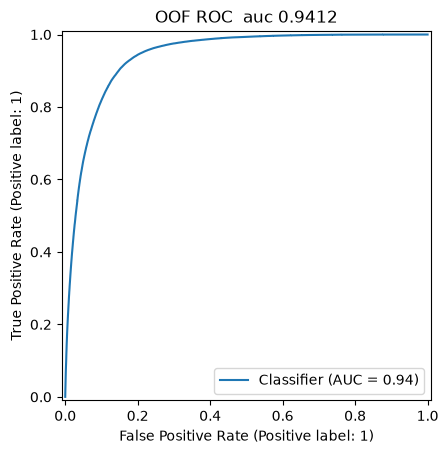

--- calibration by decile
     pred  actual      n
0  0.0003  0.0002  66867
1  0.0009  0.0006  66866
2  0.0031  0.0028  66867
3  0.0069  0.0065  66866
4  0.0124  0.0124  66867
5  0.0294  0.0277  66866
6  0.0867  0.0860  66866
7  0.2721  0.2726  66867
8  0.5409  0.5378  66866
9  0.7939  0.8000  66867
--- auc by category level
Gender                       Female     n= 295427  auc 0.9411
Gender                       Male       n= 367954  auc 0.9414
Gender                       Other      n=   5284  auc 0.9349
City_Type                    Rural      n= 123983  auc 0.9362
City_Type                    Suburban   n= 255377  auc 0.9405
City_Type                    Urban      n= 289305  auc 0.9438
Current_Car_Type             Hatchback  n=  79438  auc 0.9412
Current_Car_Type             SUV        n= 246545  auc 0.9398
Current_Car_Type             Sedan      n= 303459  auc 0.9424
Current_Car_Type             Truck      n=  39223  auc 0.9411
Home_Charging_Possible       No         n= 205988  au

In [9]:
# baseline oof score
s.oof_report(X, y, oof)

In [ ]:
# f-engineering done in s6e9.py
# engineered score
models, oof = s.train(X, y)

In [ ]:
# engineered oof score
s.oof_report(X, y, oof)

## Test

In [ ]:
X_test, _ = s.prep(test, cats)
sub = s.test(models, X_test, test[s.ID])
sub.head()